# Required Libraries + Load in Data

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
#read the csv file
serv19 = pd.read_csv("Train Services 2019-2025/services-2019.csv")

In [3]:
# Check for number of cancellations
cancellations = serv19['Service:Completely cancelled'].value_counts()
cancellations

Service:Completely cancelled
False    20545672
True       228132
Name: count, dtype: int64

# Analyzing the Data

In [4]:
serv19.head()

,Service:RDT-ID,Service:Date,Service:Type,Service:Company,Service:Train number,Service:Completely cancelled,Service:Partly cancelled,Service:Maximum delay,Stop:RDT-ID,Stop:Station code,Stop:Station name,Stop:Arrival time,Stop:Arrival delay,Stop:Arrival cancelled,Stop:Departure time,Stop:Departure delay,Stop:Departure cancelled,Stop:Platform change,Stop:Planned platform,Stop:Actual platform
0,738804,2019-01-01,Intercity,NS,1410,False,False,1,6220112,RTD,Rotterdam Centraal,NaN,NaN,NaN,2019-01-01T02:00:00+01:00,1.0,False,True,3,2
1,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220116,DT,Delft,2019-01-01T02:12:00+01:00,0.0,False,2019-01-01T02:12:00+01:00,0.0,False,False,1,1
2,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220120,GV,Den Haag HS,2019-01-01T02:20:00+01:00,1.0,False,2019-01-01T02:21:00+01:00,1.0,False,False,6,6
3,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220124,LEDN,Leiden Centraal,2019-01-01T02:35:00+01:00,0.0,False,2019-01-01T02:45:00+01:00,0.0,False,False,5b,5b
4,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220128,SHL,Schiphol Airport,2019-01-01T03:00:00+01:00,0.0,False,2019-01-01T03:02:00+01:00,0.0,False,False,3,3


In [5]:
# Display basic information about the DataFrame: 
# number of rows, columns, data types, and non-null counts

serv19.info()

<class 'pandas.DataFrame'>
RangeIndex: 20773804 entries, 0 to 20773803
Data columns (total 20 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0   Service:RDT-ID                int64  
 1   Service:Date                  str    
 2   Service:Type                  str    
 3   Service:Company               str    
 4   Service:Train number          int64  
 5   Service:Completely cancelled  bool   
 6   Service:Partly cancelled      bool   
 7   Service:Maximum delay         int64  
 8   Stop:RDT-ID                   int64  
 9   Stop:Station code             str    
 10  Stop:Station name             str    
 11  Stop:Arrival time             str    
 12  Stop:Arrival delay            float64
 13  Stop:Arrival cancelled        object 
 14  Stop:Departure time           str    
 15  Stop:Departure delay          float64
 16  Stop:Departure cancelled      object 
 17  Stop:Platform change          bool   
 18  Stop:Planned platform         s

In [6]:
id_cols = ["Service:RDT-ID", "Stop:RDT-ID"]
code_cols = ["Service:Train number"]
service_num_cols = ["Service:Maximum delay"]
stop_num_cols = ["Stop:Arrival delay", "Stop:Departure delay"]

serv19[id_cols + code_cols] = serv19[id_cols + code_cols].astype("string")

service_df = serv19.drop_duplicates(subset="Service:RDT-ID")
stop_df = serv19.drop_duplicates(subset="Stop:RDT-ID")

print("Service-level numeric summary")
display(service_df[service_num_cols].describe().T)

print("Stop-level numeric summary")
display(stop_df[stop_num_cols].describe().T)

print("Boolean summary")
display(serv19.select_dtypes(include=["bool"]).describe().T)

print("Categorical / code summary")
display(serv19.select_dtypes(include=["object", "str", "category"]).describe().T)

Service-level numeric summary


,count,mean,std,min,25%,50%,75%,max
Service:Maximum delay,2369241.0,1.747942,4.361376,-74.0,0.0,1.0,2.0,999.0


Stop-level numeric summary


,count,mean,std,min,25%,50%,75%,max
Stop:Arrival delay,18287264.0,0.635961,2.757499,-92.0,0.0,0.0,0.0,999.0
Stop:Departure delay,18562837.0,0.686767,2.521622,-1351.0,0.0,0.0,1.0,999.0


Boolean summary


,count,unique,top,freq
Service:Completely cancelled,20773804,2,False,20545672
Service:Partly cancelled,20773804,2,False,19811322
Stop:Platform change,20773804,2,False,20315836


Categorical / code summary


,count,unique,top,freq
Service:RDT-ID,20773804,2369241,762648,34
Service:Date,20773804,365,2019-11-29,68509
Service:Type,20773804,25,Sprinter,9787865
Service:Company,20773804,21,NS,14518938
Service:Train number,20773804,28653,7384,8849
Stop:RDT-ID,20773804,20773804,6220112,1
Stop:Station code,20746920,529,UT,465645
Stop:Station name,20773804,533,Utrecht Centraal,465645
Stop:Arrival time,18287264,475336,2019-12-31T07:54:00+01:00,81
Stop:Arrival cancelled,18287264,2,False,17838957


# Dealing with Missing Values

In [7]:
total = serv19.isnull().sum().sort_values(ascending=False)
percent = (serv19.isnull().sum()/serv19.isnull().count()).sort_values(ascending=False)
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
missing_data

,Total,Percent
Stop:Arrival delay,2486540,0.119696
Stop:Arrival cancelled,2486540,0.119696
Stop:Arrival time,2486540,0.119696
Stop:Departure time,2210967,0.106431
Stop:Departure delay,2210967,0.106431
Stop:Departure cancelled,2210967,0.106431
Stop:Planned platform,754046,0.036298
Stop:Actual platform,754046,0.036298
Stop:Station code,26884,0.001294
Service:Type,0,0.000000


In [8]:
#Numerical columns: fill with median and create missing indicator
#Categorical columns: fill with 'Unknown'

num_cols = serv19.select_dtypes(include=np.number).columns
cat_cols = serv19.select_dtypes(exclude=np.number).columns

for col in num_cols:
    if serv19[col].isna().any():
        serv19[f"{col}_missing"] = serv19[col].isna().astype(int)
        serv19[col] = serv19[col].fillna(serv19[col].median())

for col in cat_cols:
    serv19[col] = serv19[col].fillna("Unknown")

In [9]:
# Check for duplicates
serv19.duplicated().sum()

np.int64(0)

# Univariate & Bivariate Analysis

## Univariate

### Univariate: Numerical

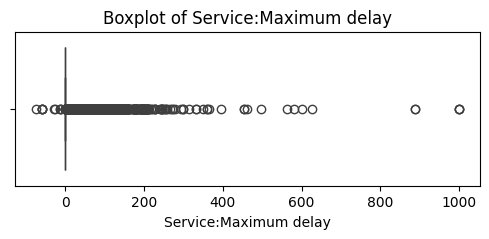

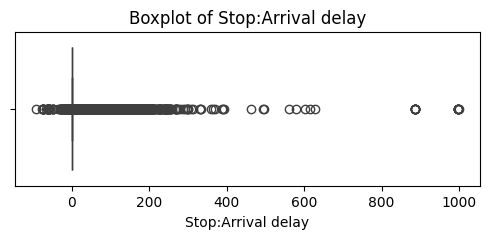

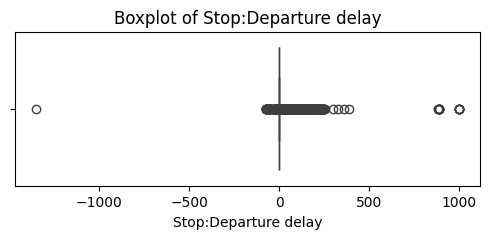

In [10]:
for col in num_cols:
    plt.figure(figsize=(6, 2))
    sns.boxplot(x=serv19[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [11]:
# Univariate analysis for duration_minutes
duration = serv19["duration_minutes"].dropna()

# Categorize duration into groups
bins = [0, 15, 30, 60, 120, np.inf]
labels = ["0–15 min", "16–30 min", "31–60 min", "61–120 min", "120+ min"]

serv19["duration_category"] = pd.cut(
    serv19["duration_minutes"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Counts per category
duration_counts = serv19["duration_category"].value_counts().sort_index()
display(duration_counts)

# Pie chart
plt.figure(figsize=(6, 6))
plt.pie(duration_counts, labels=duration_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Duration Categories")
plt.show()

KeyError: 'duration_minutes'

### Univariate: Categorical

C:\Users\johan\AppData\Local\Temp\ipykernel_6404\1299019976.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")


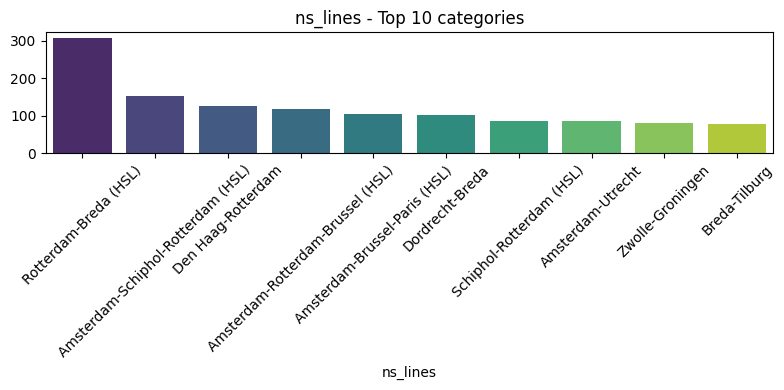

C:\Users\johan\AppData\Local\Temp\ipykernel_6404\1299019976.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")
C:\Users\johan\AppData\Local\Temp\ipykernel_6404\1299019976.py:8: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


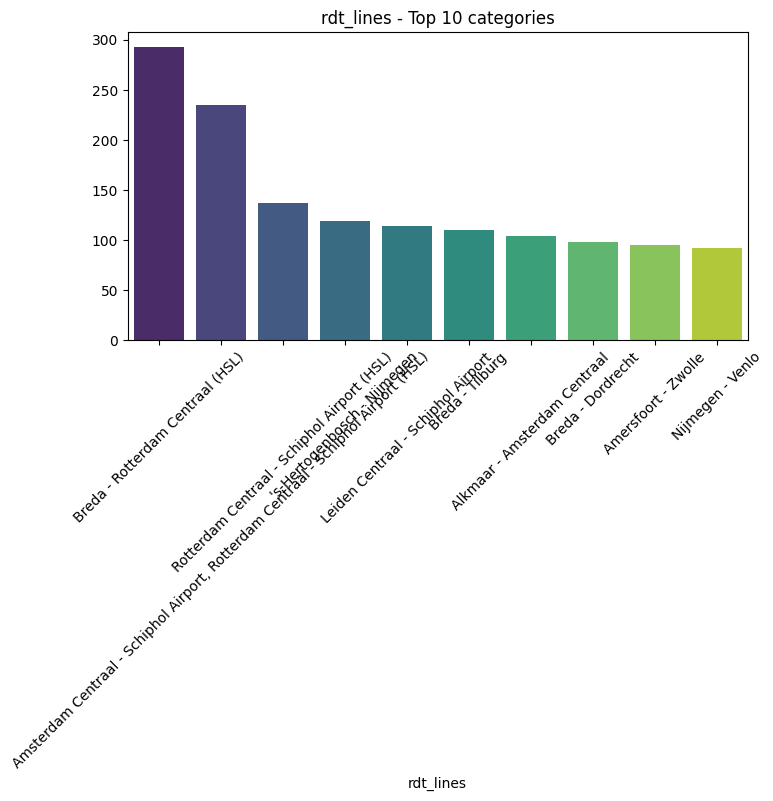

C:\Users\johan\AppData\Local\Temp\ipykernel_6404\1299019976.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")


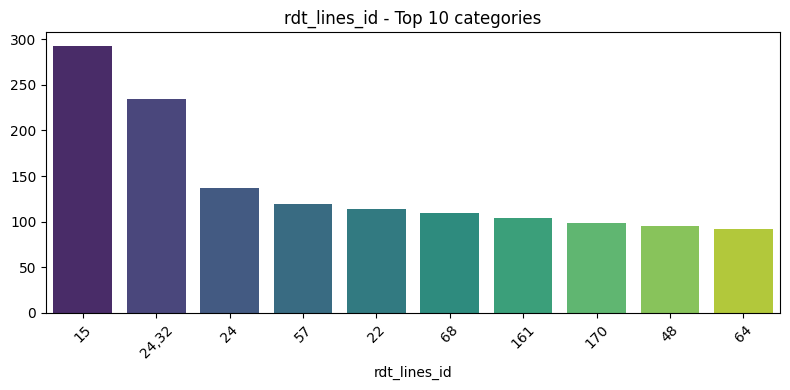

C:\Users\johan\AppData\Local\Temp\ipykernel_6404\1299019976.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")
C:\Users\johan\AppData\Local\Temp\ipykernel_6404\1299019976.py:8: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


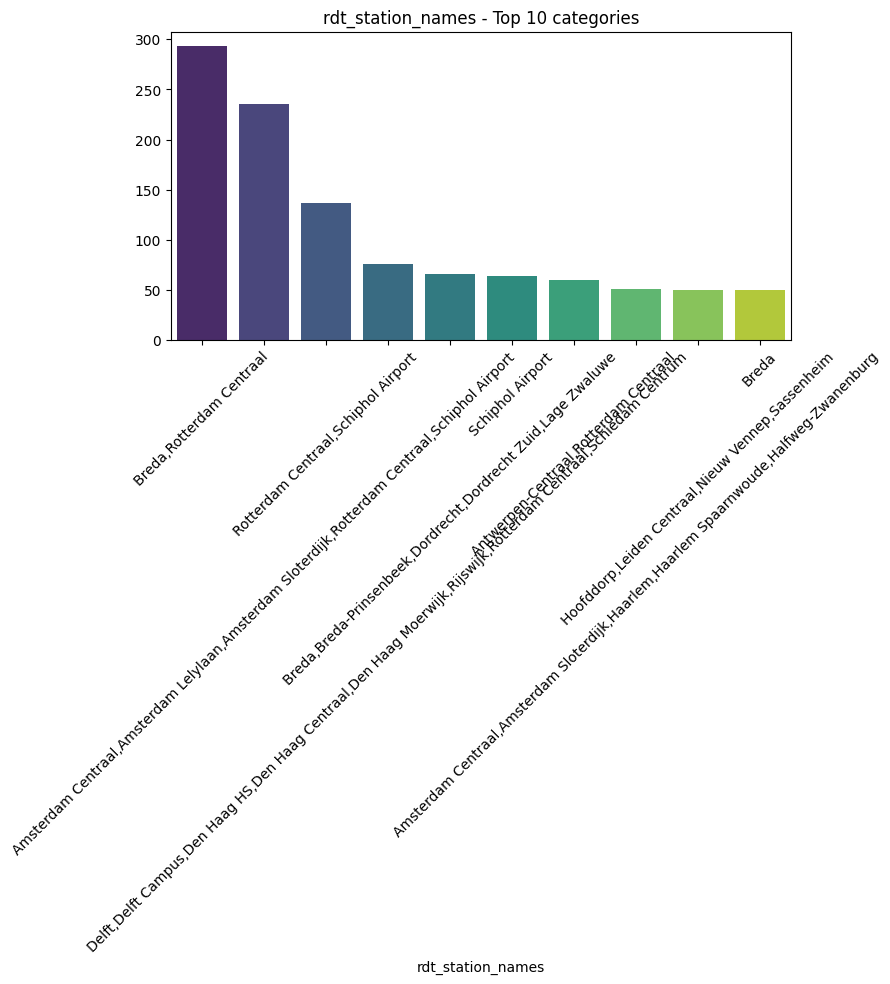

C:\Users\johan\AppData\Local\Temp\ipykernel_6404\1299019976.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")


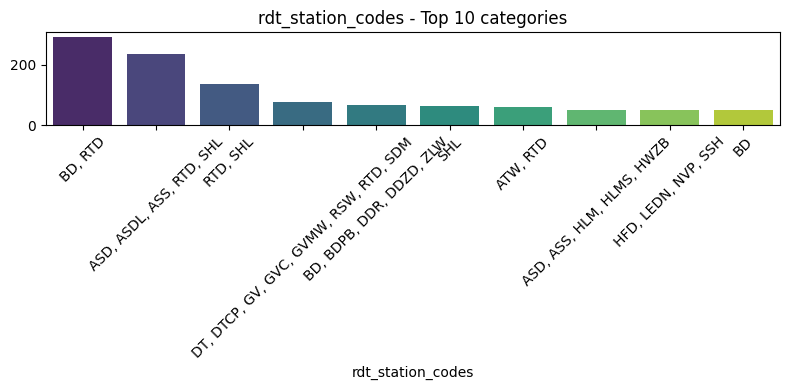

C:\Users\johan\AppData\Local\Temp\ipykernel_6404\1299019976.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")


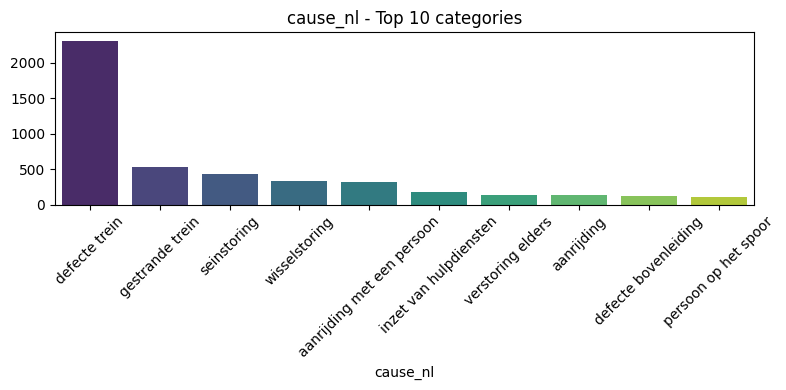

C:\Users\johan\AppData\Local\Temp\ipykernel_6404\1299019976.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")


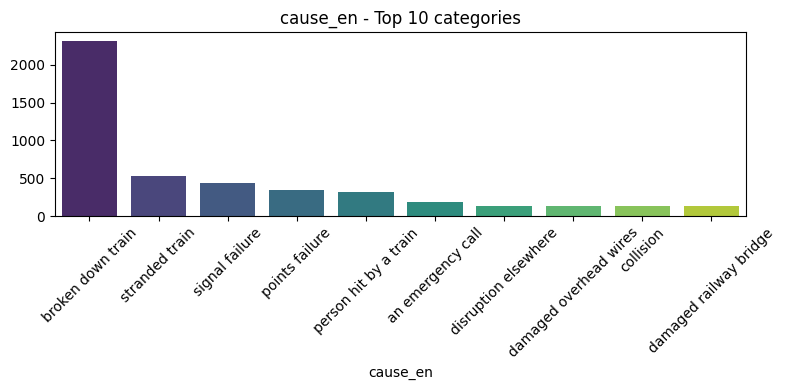

C:\Users\johan\AppData\Local\Temp\ipykernel_6404\1299019976.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")


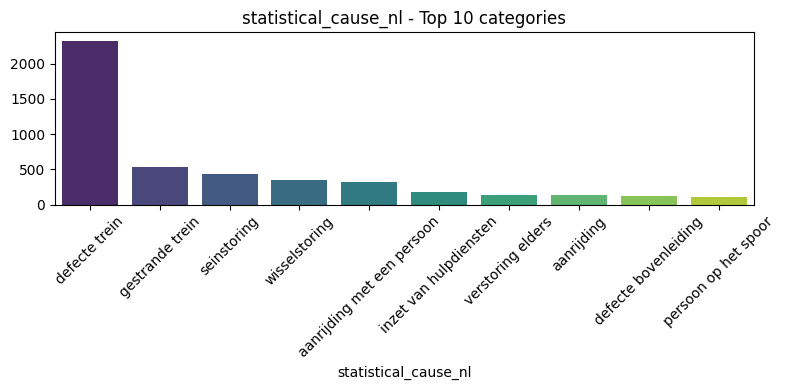

C:\Users\johan\AppData\Local\Temp\ipykernel_6404\1299019976.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")


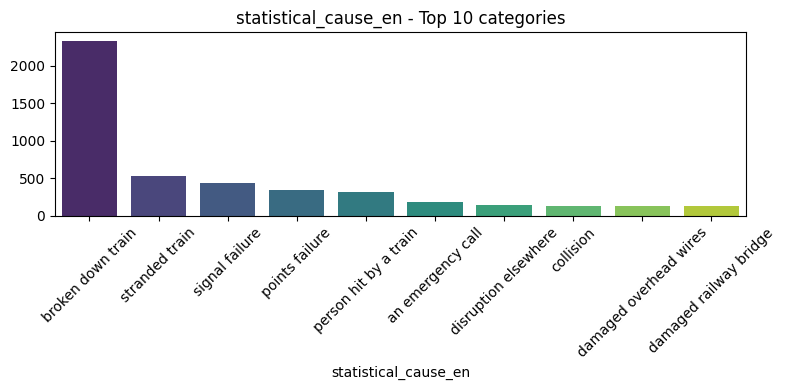

C:\Users\johan\AppData\Local\Temp\ipykernel_6404\1299019976.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")


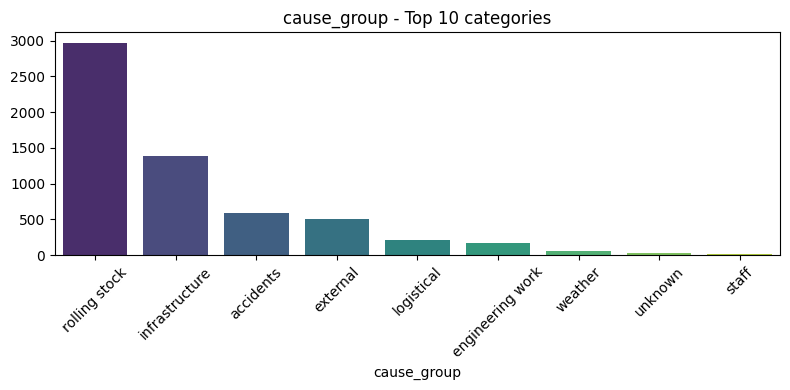

C:\Users\johan\AppData\Local\Temp\ipykernel_6404\1299019976.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")


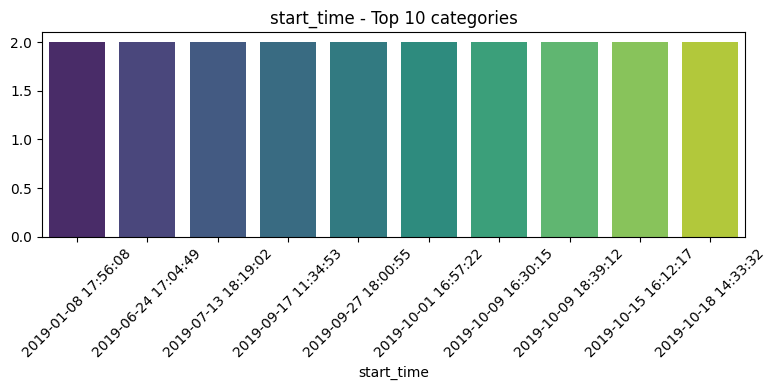

C:\Users\johan\AppData\Local\Temp\ipykernel_6404\1299019976.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")


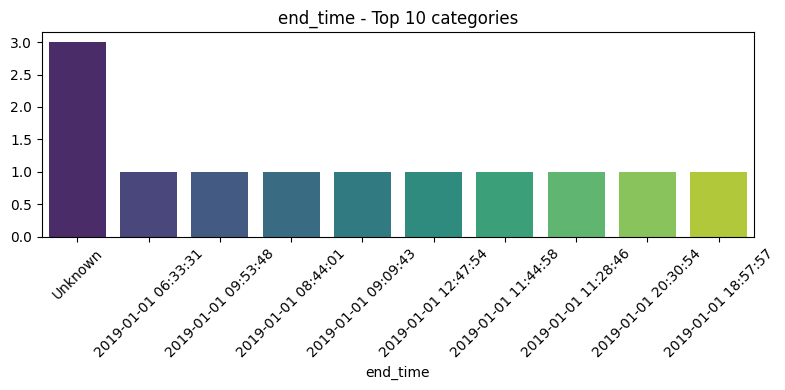

In [ ]:
top_n = 10
for col in cat_cols:
    counts = serv19[col].astype(str).value_counts().head(top_n)
    plt.figure(figsize=(8, 4))
    sns.barplot(x=counts.index, y=counts.values, palette="viridis")
    plt.title(f"{col} - Top {top_n} categories")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## Bivariate

### Bivariate: Numerical

In [ ]:
#statistic summary of serv19[num_cols]
serv19[num_cols].describe()

,rdt_id,duration_minutes
count,5940.000000,5940.000000
mean,28205.500000,96.914310
std,1714.874631,297.294805
min,25236.000000,0.000000
25%,26720.750000,12.000000
50%,28205.500000,40.000000
75%,29690.250000,113.000000
max,31175.000000,17011.000000


<Figure size 1000x600 with 0 Axes>

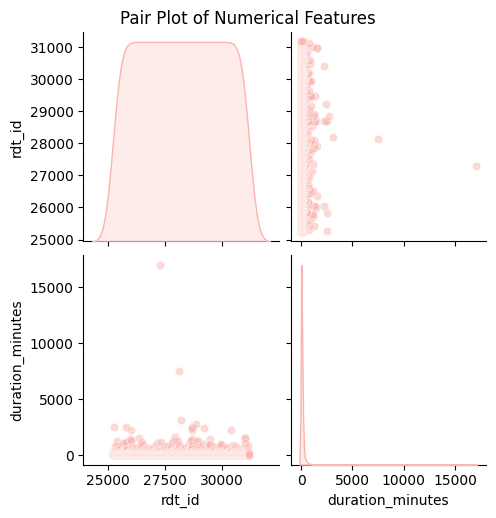

In [ ]:
sns.set_palette("Pastel1")

plt.figure(figsize=(10, 6))

sns.pairplot(serv19[num_cols], diag_kind='kde', plot_kws={'alpha': 0.5})

plt.suptitle('Pair Plot of Numerical Features', y=1.02)
plt.show()

### Bivariate: Categorical

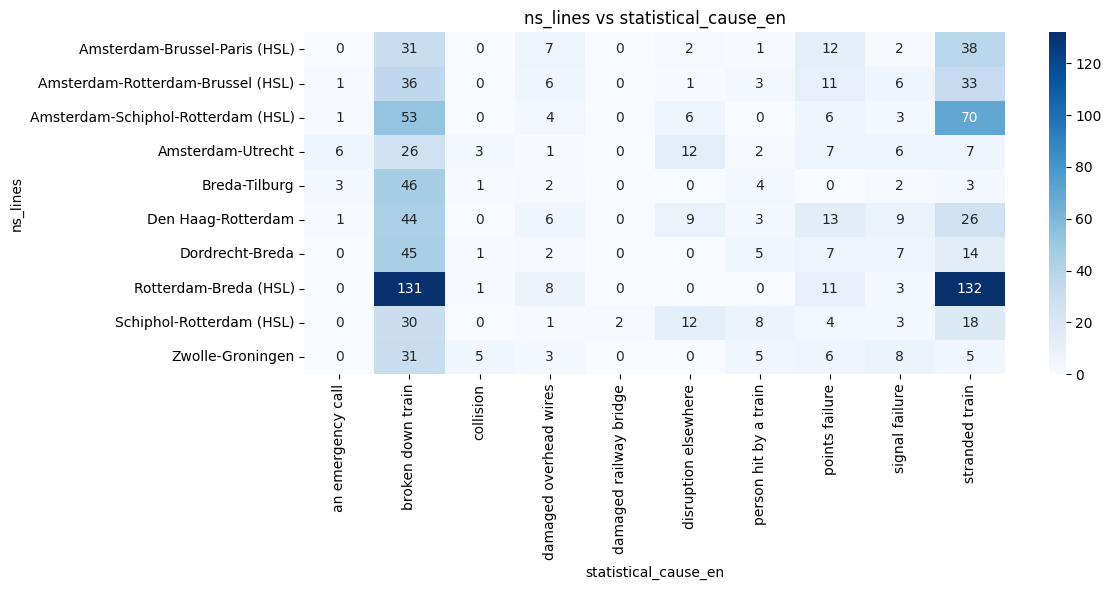

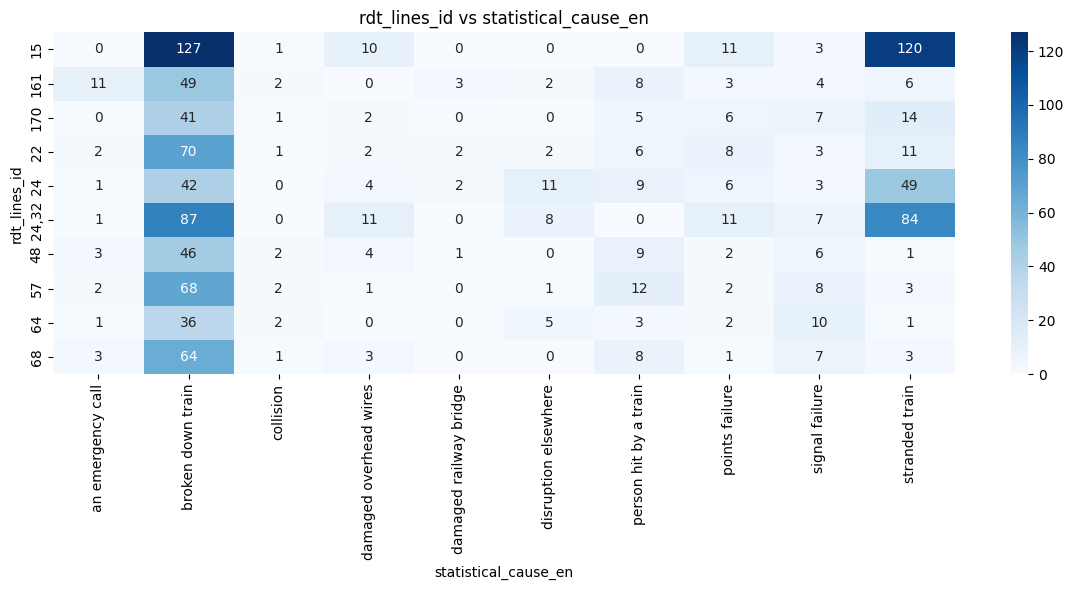

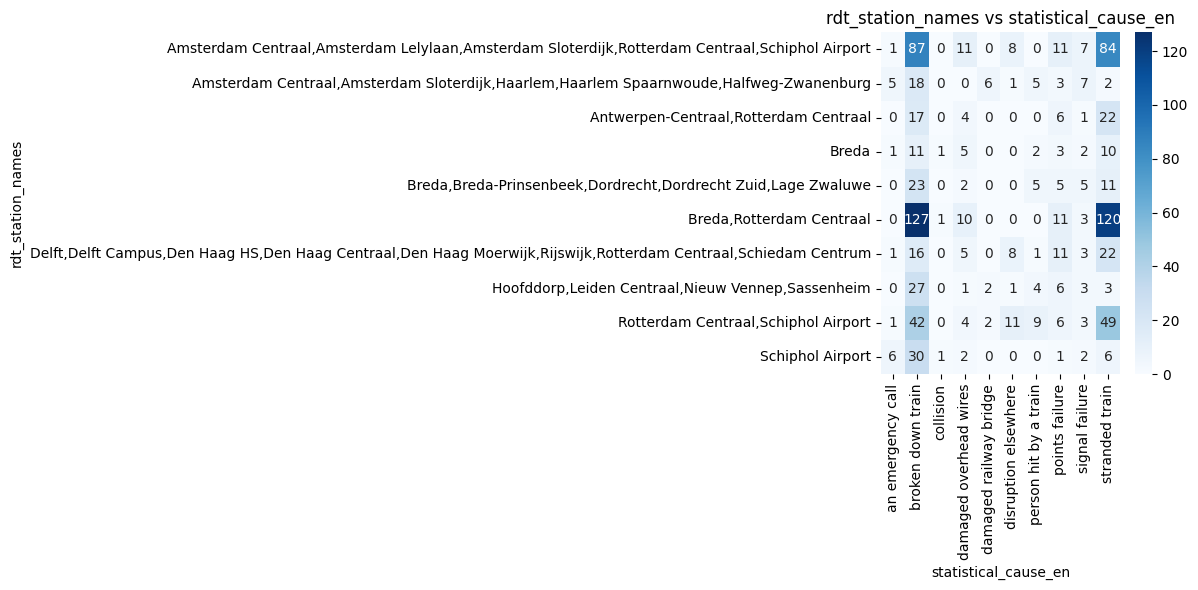

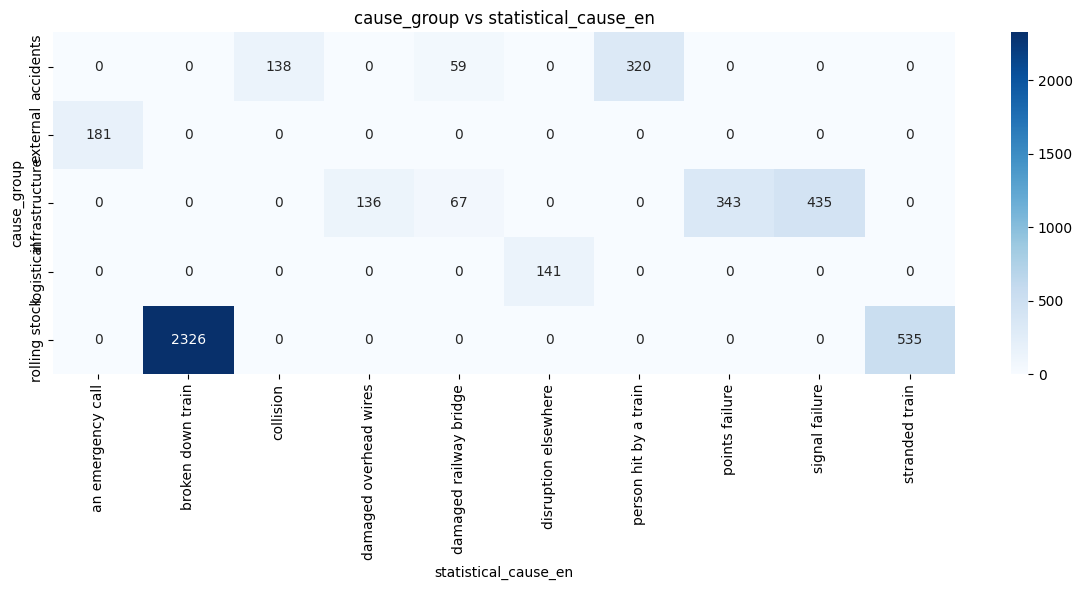

In [ ]:
def plot_categorical_heatmap(df, col1, col2, top_n=10):
    tmp = df[[col1, col2]].dropna().astype(str)

    top1 = tmp[col1].value_counts().head(top_n).index
    top2 = tmp[col2].value_counts().head(top_n).index

    tmp = tmp[tmp[col1].isin(top1) & tmp[col2].isin(top2)]
    ct = pd.crosstab(tmp[col1], tmp[col2])

    plt.figure(figsize=(12, 6))
    sns.heatmap(ct, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{col1} vs {col2}")
    plt.tight_layout()
    plt.show()

plot_categorical_heatmap(serv19, "ns_lines", "statistical_cause_en")
plot_categorical_heatmap(serv19, "rdt_lines_id", "statistical_cause_en")
plot_categorical_heatmap(serv19, "rdt_station_names", "statistical_cause_en")
plot_categorical_heatmap(serv19, "cause_group", "statistical_cause_en")